# Machine Learning Project - Setiment Analysis Classifier

### Đề tài: Phân loại **Naïve Bayesian** và kỹ thuật ước lượng **Laplace (Laplace Estimator)**

**Mô tả**: Áp dụng Lý thuyết xác suất **Bayes’ Theorem**.

- Triển khai bộ **phân loại Naïve Bayesian** để phân loại dữ liệu văn bản (Text Classification) hoặc dữ liệu có thuộc tính rời rạc.
- Tập trung giải quyết vấn đề **xác suất bằng không (zero probability)** bằng cách sử dụng **Laplace Estimator (hay còn gọi là Laplace Correction)**.

**Yêu cầu Python**: Sử dụng thư viện Scikit-learn (hoặc triển khai thủ công) để xây dựng mô hình, đồng thời chứng minh và áp dụng hiệu quả của Laplace Estimator trong Python.

In [3]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import sklearn.naive_bayes as nb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from IPython.display import clear_output

In [6]:
#load dataset english/vietnamese sentiment analysis
eng = pd.read_csv('sentiment_eng_31k.csv')
vie = pd.read_csv('sentiment_vie_30k.csv')
df = pd.concat([eng, vie], ignore_index=True).dropna(subset=["text"])
df

,text,sentiment
0,"Cooking microwave pizzas, yummy",positive
1,Any plans of allowing sub tasks to show up in ...,neutral
2,"I love the humor, I just reworded it. Like sa...",positive
3,naw idk what ur talkin about,neutral
4,That sucks to hear. I hate days like that,negative
...,...,...
62687,Không đáng tiền,negative
62688,Quần rất đẹp,positive
62689,Hàng đẹp đúng giá tiền,positive
62690,Chất vải khá ổn,positive


In [7]:
X = df['text']
y = df['sentiment']

#split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#vectorize text data
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## 1. Model without Laplace Estimator (Laplace Smoothing)

/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/naive_bayes.py:1045: RuntimeWarning: divide by zero encountered in log
  logged = np.log(comp_count / comp_count.sum(axis=1, keepdims=True))


Predictions without Laplace smoothing: ['positive' 'negative' 'negative' ... 'positive' 'neutral' 'neutral']
Accuracy without Laplace smoothing: 0.627094303494495
              precision    recall  f1-score   support

    negative       0.56      0.58      0.57      3151
     neutral       0.45      0.49      0.47      3209
    positive       0.77      0.72      0.75      6174

    accuracy                           0.63     12534
   macro avg       0.59      0.60      0.59     12534
weighted avg       0.64      0.63      0.63     12534



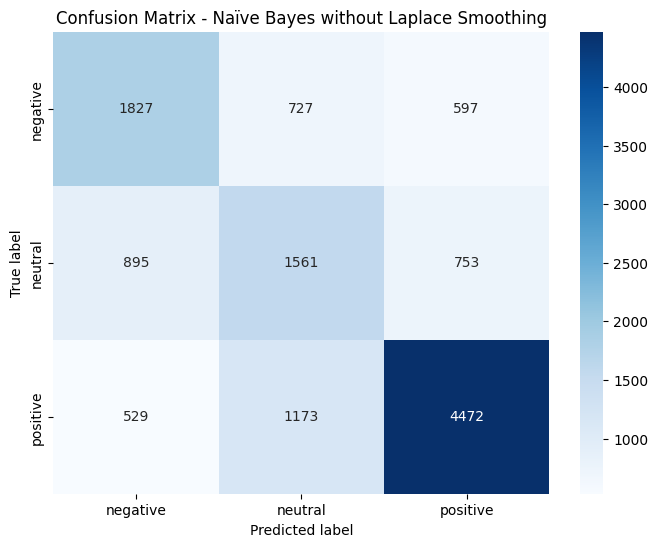

In [11]:
#model training without Laplace smoothing
modelNBC = nb.ComplementNB(alpha=0.0)
modelNBC.fit(X_train_vec, y_train)

#make predictions
y_pred_1 = modelNBC.predict(X_test_vec)
print('Predictions without Laplace smoothing:', y_pred_1)
#evaluate model
print("Accuracy without Laplace smoothing:", accuracy_score(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

#Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelNBC.classes_, yticklabels=modelNBC.classes_)
plt.title('Confusion Matrix - Naïve Bayes without Laplace Smoothing')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## 2. Model with Laplace Estimator (Laplace Correction)

Predictions with Laplace smoothing: ['positive' 'positive' 'positive' ... 'positive' 'neutral' 'neutral']
Accuracy with Laplace smoothing: 0.6436093824796554
              precision    recall  f1-score   support

    negative       0.63      0.55      0.59      3151
     neutral       0.46      0.57      0.51      3209
    positive       0.77      0.73      0.75      6174

    accuracy                           0.64     12534
   macro avg       0.62      0.62      0.62     12534
weighted avg       0.66      0.64      0.65     12534



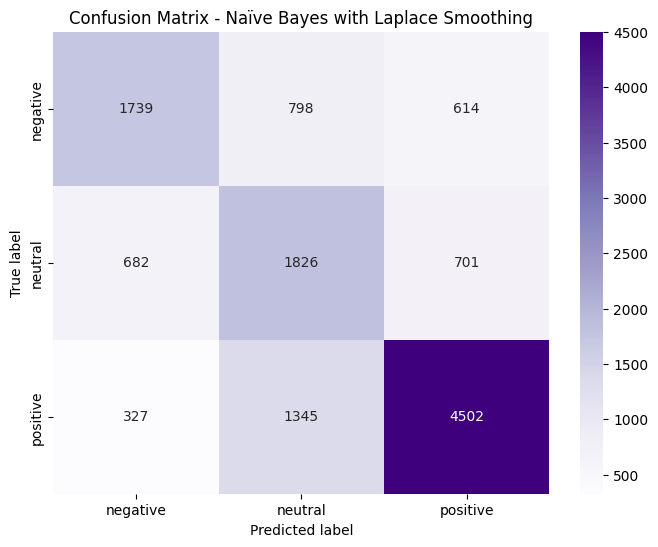

In [12]:
#model training with Laplace smoothing (alpha=1)
modelNBC_laplace = nb.ComplementNB(alpha=1.0)
modelNBC_laplace.fit(X_train_vec, y_train)
#make predictions
y_pred_2 = modelNBC_laplace.predict(X_test_vec)
print('Predictions with Laplace smoothing:', y_pred_2)
#evaluate model
print("Accuracy with Laplace smoothing:", accuracy_score(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

#Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=modelNBC_laplace.classes_, yticklabels=modelNBC_laplace.classes_)
plt.title('Confusion Matrix - Naïve Bayes with Laplace Smoothing')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## 3. Comparison between two models of Naive Bayes Classifier demonstrates the effectiveness of Laplace Estimator

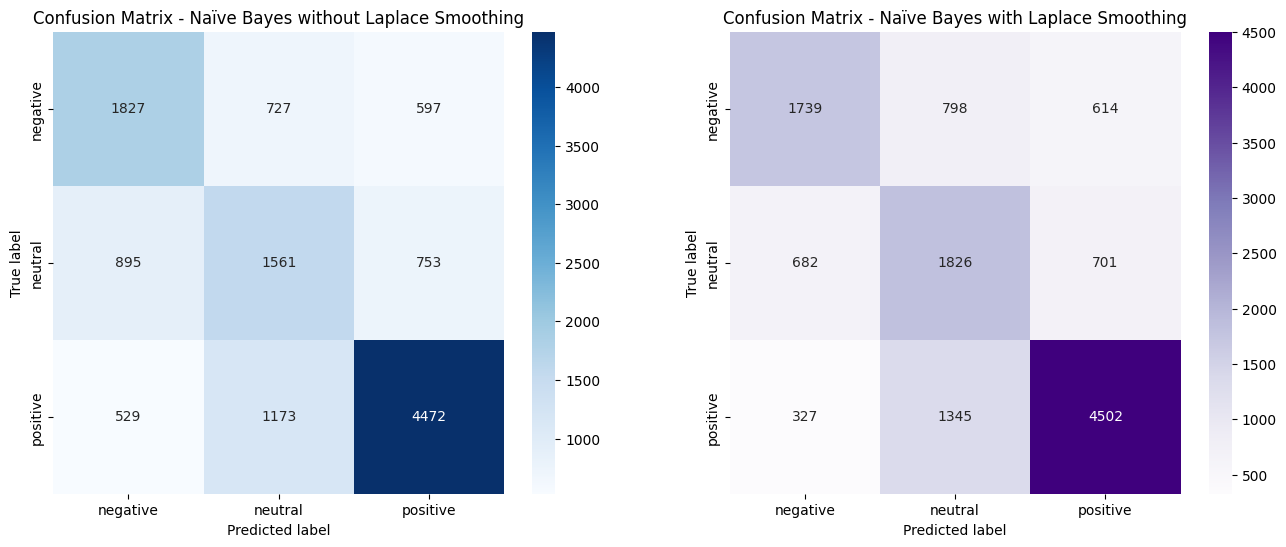

In [13]:
#Compare confusion matrices between models with and without Laplace smoothing
cm_no_laplace = confusion_matrix(y_test, y_pred_1)
cm_laplace = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_no_laplace, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelNBC.classes_, yticklabels=modelNBC.classes_)
plt.title('Confusion Matrix - Naïve Bayes without Laplace Smoothing')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.subplot(1, 2, 2)
sns.heatmap(cm_laplace, annot=True, fmt='d', cmap='Purples', 
            xticklabels=modelNBC_laplace.classes_, yticklabels=modelNBC_laplace.classes_)
plt.title('Confusion Matrix - Naïve Bayes with Laplace Smoothing')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


Summary (Macro-average scores)
----------------------------------------
Without Laplace: Precision=0.594, Recall=0.597, F1=0.595
With Laplace:    Precision=0.622, Recall=0.617, F1=0.616


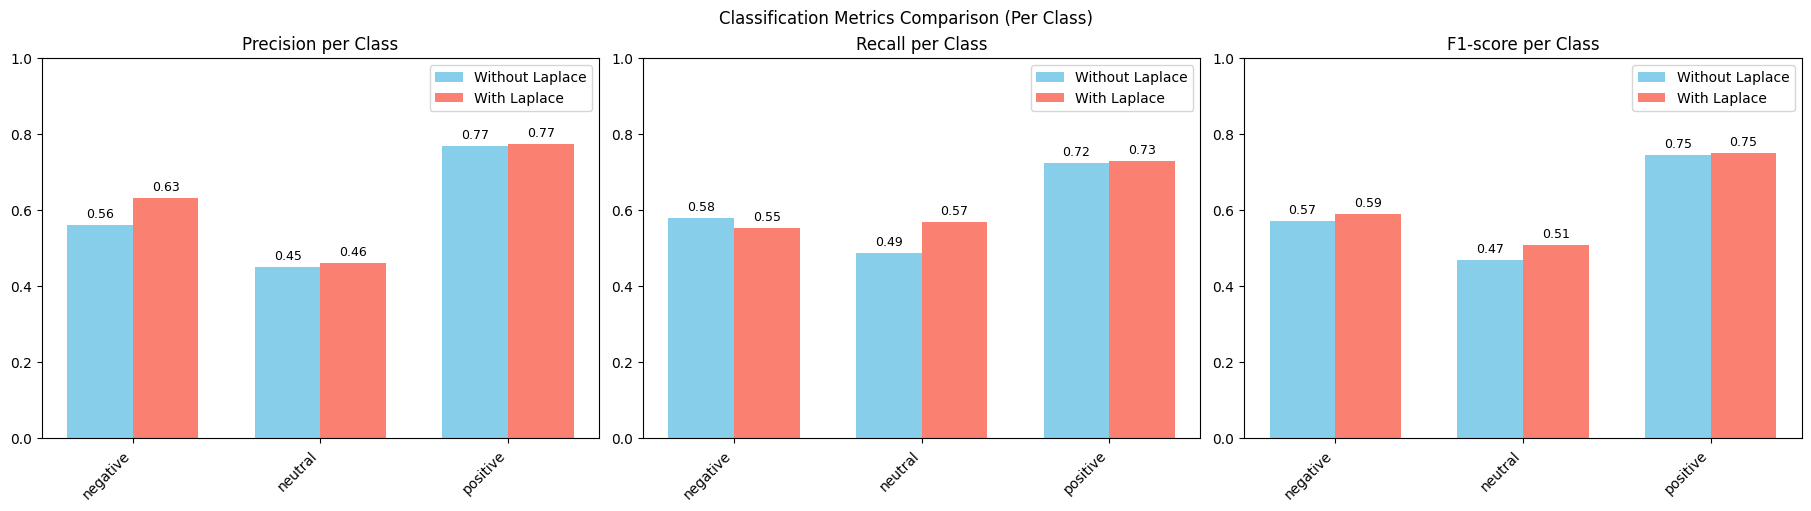

In [14]:
# Get class labels in consistent order
labels = list(modelNBC.classes_)

# Compute precision, recall, f1 per class for both models
p1, r1, f1_scores_1, _ = precision_recall_fscore_support(y_test, y_pred_1, labels=labels, zero_division=0)
p2, r2, f2_scores_2, _ = precision_recall_fscore_support(y_test, y_pred_2, labels=labels, zero_division=0)

# Also print a small table of macro averages to summarize
macro1_precision = np.mean(p1)
macro1_recall = np.mean(r1)
macro1_f1 = np.mean(f1_scores_1)

macro2_precision = np.mean(p2)
macro2_recall = np.mean(r2)
macro2_f1 = np.mean(f2_scores_2)

print('\nSummary (Macro-average scores)')
print('-' * 40)
print(f"Without Laplace: Precision={macro1_precision:.3f}, Recall={macro1_recall:.3f}, F1={macro1_f1:.3f}")
print(f"With Laplace:    Precision={macro2_precision:.3f}, Recall={macro2_recall:.3f}, F1={macro2_f1:.3f}")

#Bar chart comparison of classification report between models with and without Laplace smoothing

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Precision
axes[0].bar(x - width/2, p1, width, label='Without Laplace', color='skyblue')
axes[0].bar(x + width/2, p2, width, label='With Laplace', color='salmon')
axes[0].set_title('Precision per Class')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Recall
axes[1].bar(x - width/2, r1, width, label='Without Laplace', color='skyblue')
axes[1].bar(x + width/2, r2, width, label='With Laplace', color='salmon')
axes[1].set_title('Recall per Class')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()

# F1-score
axes[2].bar(x - width/2, f1_scores_1, width, label='Without Laplace', color='skyblue')
axes[2].bar(x + width/2, f2_scores_2, width, label='With Laplace', color='salmon')
axes[2].set_title('F1-score per Class')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
axes[2].set_ylim(0, 1)
axes[2].legend()

# Annotate values on bars
for ax, vals1, vals2 in zip(axes, [p1, r1, f1_scores_1], [p2, r2, f2_scores_2]):
    for i in range(len(labels)):
        ax.text(i - width/2, vals1[i] + 0.02, f"{vals1[i]:.2f}", ha='center', fontsize=9)
        ax.text(i + width/2, vals2[i] + 0.02, f"{vals2[i]:.2f}", ha='center', fontsize=9)

fig.suptitle('Classification Metrics Comparison (Per Class)')
plt.show()


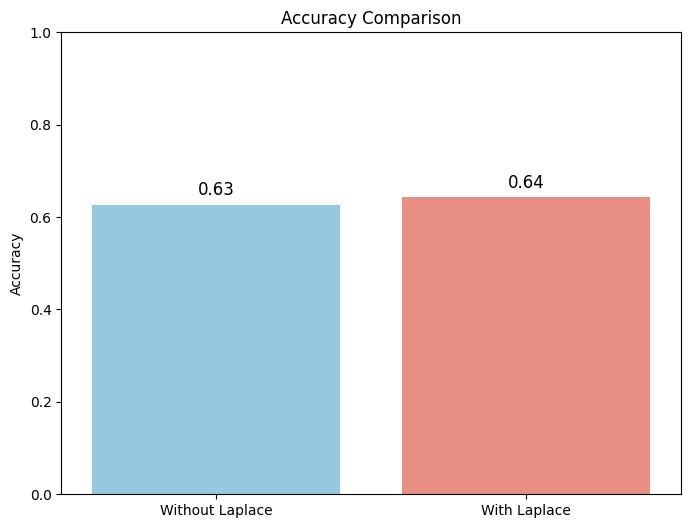

/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/naive_bayes.py:130: RuntimeWarning: invalid value encountered in subtract
  return jll - np.atleast_2d(log_prob_x).T


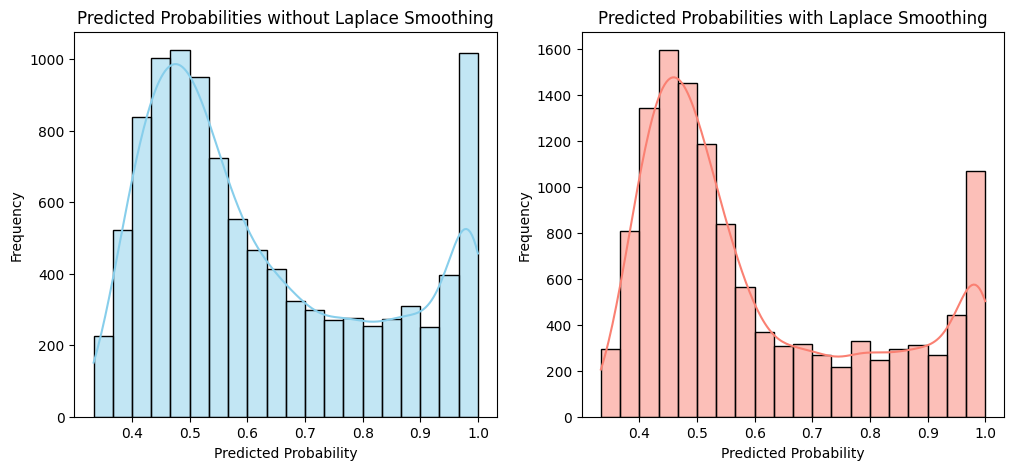

In [25]:
# Plot compare accuracy between models with and without Laplace smoothing
accuracies = [accuracy_score(y_test, y_pred_1), accuracy_score(y_test, y_pred_2)]
labels = ['Without Laplace', 'With Laplace']
plt.figure(figsize=(8,6))
sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'salmon'], hue=labels, legend=False)
plt.ylim(0, 1)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)
plt.show()

#plot distribution of predicted probabilities for both models
y_prob_1 = modelNBC.predict_proba(X_test_vec)
y_prob_2 = modelNBC_laplace.predict_proba(X_test_vec)
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.histplot(np.max(y_prob_1, axis=1), bins=20, color='skyblue', kde=True)
plt.title('Predicted Probabilities without Laplace Smoothing')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.histplot(np.max(y_prob_2, axis=1), bins=20, color='salmon', kde=True)
plt.title('Predicted Probabilities with Laplace Smoothing')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

# Demo App

In [26]:
# Demo app lication of Naive Bayes classifier with and without Laplace Estimator use ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output
# Create text area for input
text_area = widgets.Text(
    value='',
    placeholder='Enter text to classify here...',
    description='Input Text:',
    disabled=False,
    layout=widgets.Layout(width='20%', height='Auto')
)
# Create button to trigger prediction
predict_button = widgets.Button(
    description='Predict Sentiment',
    disabled=False,
    button_style='success',
    tooltip='Click to classify text',
    icon='check'
)
# Output area to display results
output_area = widgets.Output()
# Define button click event handler
def on_predict_button_clicked(b):
    with output_area:
        clear_output()
        input_text = text_area.value.strip()
        if input_text:
            input_vec = vectorizer.transform([input_text])
            pred_without_laplace = modelNBC.predict(input_vec)[0]
            pred_with_laplace = modelNBC_laplace.predict(input_vec)[0]
            prob_without_laplace = modelNBC.predict_proba(input_vec)[0]
            prob_with_laplace = modelNBC_laplace.predict_proba(input_vec)[0]
            print("=" * 80)
            print("PREDICTION RESULT")
            print("=" * 80)
            print(f"Input Text: \"{input_text}\"")
            print("-" * 80)
            print(f"Without Laplace Smoothing: {pred_without_laplace} (confidence: {max(prob_without_laplace):.4f})")
            print(f"With Laplace Smoothing:    {pred_with_laplace} (confidence: {max(prob_with_laplace):.4f})")
            if pred_without_laplace == pred_with_laplace:
                print("✓ Both models agree")
            else:
                print("✗ Models disagree - Laplace smoothing impact!")
        else:
            print("Please enter some text to classify.")
# Attach event handler to button
predict_button.on_click(on_predict_button_clicked)
# Display the widgets
display(text_area, predict_button, output_area)

Text(value='', description='Input Text:', layout=Layout(height='Auto', width='20%'), placeholder='Enter text t…

Button(button_style='success', description='Predict Sentiment', icon='check', style=ButtonStyle(), tooltip='Cl…

Output()